In [ ]:
import psycopg2
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
# Ahora vamos a extraer los datos de la base en local y analizarlos 

DB_CONFIG = {
    "host": "localhost",
    "port": 5432,
    "database": "postgres",
    "user": "postgres",
    "password": "IK008626"
}

conn = psycopg2.connect(**DB_CONFIG)

cur = conn.cursor()

cur.execute("SELECT * FROM divisas;")

filas = cur.fetchall()

nombre_columnas = [desc[0] for desc in cur.description]

cur.close()
conn.close()

In [16]:
# Pasamos los datos a un DataFrame para su análisis y visualización

df = pd.DataFrame(filas, columns=nombre_columnas)

print(df.head())

        fecha     aud     bgn     brl     cad     chf     cny     czk     dkk  \
0  2021-12-27  1.5615  1.9558  6.3101  1.4393  1.0331  7.1947  24.858  7.4364   
1  2022-01-03  1.5711  1.9558  6.4124  1.4405  1.0382  7.2086  24.622  7.4383   
2  2022-01-10  1.5770  1.9558  6.3639  1.4310  1.0463  7.2481  24.429  7.4404   
3  2022-01-17  1.5758  1.9558  6.2389  1.4206  1.0392  7.2100  24.363  7.4423   
4  2022-01-24  1.5830  1.9558  6.1068  1.4218  1.0365  7.1214  24.486  7.4430   

       gbp  ...     php     pln     ron    rub      sek     sgd     thb  \
0  0.84028  ...  57.763  4.5969  4.9490  85.30  10.2503  1.5279  37.653   
1  0.83664  ...  57.948  4.5668  4.9462  85.40  10.2883  1.5345  37.778   
2  0.83453  ...  58.300  4.5381  4.9444  85.84  10.2763  1.5378  37.997   
3  0.83462  ...  58.387  4.5258  4.9449  86.87  10.3502  1.5307  37.508   
4  0.83504  ...  57.570  4.5707  4.9456  88.08  10.4904  1.5147  37.237   

       try     usd      zar  
0  15.2335  1.1326  18.0625  
1 

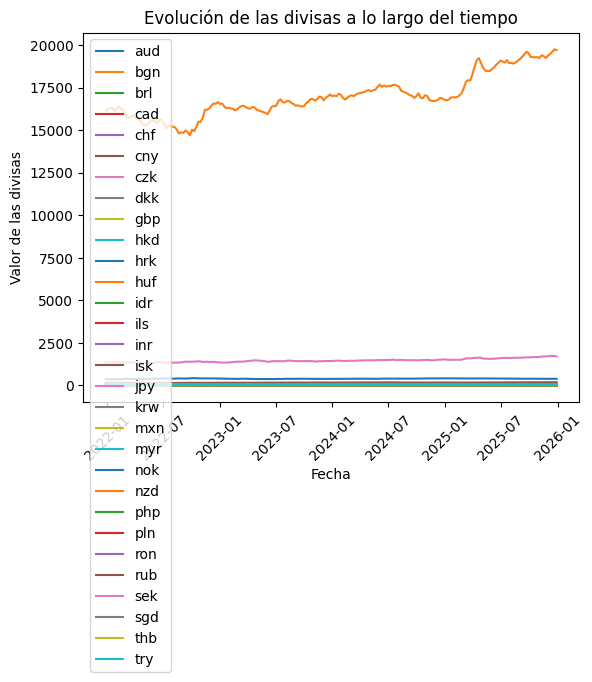

In [42]:
x = df["fecha"]
y = df.drop(columns=["fecha"])

y_filtered = y.loc[:, (y <= 400000).all()]

plt.plot(x, y_filtered)
plt.xlabel("Fecha")
plt.ylabel("Valor de las divisas")
plt.title("Evolución de las divisas a lo largo del tiempo")
plt.legend(nombre_columnas[1:], loc="upper left")
plt.xticks(rotation=45)
plt.show()

In [32]:
# Desviación estandar de cada divisa

y = y.drop(columns="bgn")

desviaciones_estandar = y.std()

desviaciones_estandar_normalizada = y.std() / y.mean()

print(desviaciones_estandar_normalizada.sort_values(ascending=False))

try    0.352689
rub    0.106113
jpy    0.087588
brl    0.079215
idr    0.072793
inr    0.070683
mxn    0.070521
zar    0.070162
krw    0.069030
nzd    0.062868
nok    0.062744
ils    0.058154
aud    0.056415
cny    0.055897
cad    0.055793
php    0.053723
pln    0.044176
usd    0.042405
hkd    0.041357
myr    0.039345
sek    0.036234
huf    0.034651
chf    0.033159
thb    0.028605
isk    0.028250
sgd    0.023427
czk    0.020504
gbp    0.018547
ron    0.010329
hrk    0.002288
dkk    0.001336
dtype: float64


In [41]:
# Variación de valor respecto al euro

rendimiento_total = (y.iloc[0]-y.iloc[-1]) / y.iloc[-1]
print(rendimiento_total.sort_values(ascending=False))

chf    0.110860
mxn    0.096197
pln    0.087869
czk    0.024734
thb    0.016330
sgd    0.011385
isk    0.001357
bgn    0.000000
dkk   -0.004365
myr   -0.010361
brl   -0.028408
ron   -0.028865
hkd   -0.034412
gbp   -0.036520
usd   -0.036741
huf   -0.044045
sek   -0.052521
ils   -0.062527
zar   -0.075269
cad   -0.105969
aud   -0.111219
cny   -0.125849
nok   -0.155781
php   -0.165648
idr   -0.182534
nzd   -0.184024
inr   -0.202745
krw   -0.205760
jpy   -0.290835
try   -0.698281
hrk         NaN
rub         NaN
dtype: float64
